# 决策树（Decision Tree）

决策树是一种树形结构的监督学习算法，既可用于**分类**，也可用于**回归**。

核心思想：从根节点出发，每次选择一个最优特征对数据进行分裂，直到叶节点给出预测结果。

树的组成：
- **根节点（Root）**：整个数据集，第一次分裂的起点
- **内部节点（Internal Node）**：每次分裂基于某个特征的判断条件
- **叶节点（Leaf）**：最终预测结果（分类标签 或 回归均值）

## 1. 信息熵（Information Entropy）

熵来源于信息论，用来衡量**数据的不纯度（混乱程度）**。

$$H(D) = -\sum_{k=1}^{K} p_k \log_2 p_k$$

- $p_k$：数据集 $D$ 中第 $k$ 类样本占总样本的比例
- $H(D)$ 越大，数据越混乱（越难分类）；越小，数据越纯净
- 当所有样本属于同一类时，$H(D) = 0$（最纯净）
- 当各类别样本均等时，$H(D)$ 达到最大值 $\log_2 K$

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\3050682126.py:20: UserWarning: Glyph 20363 (\

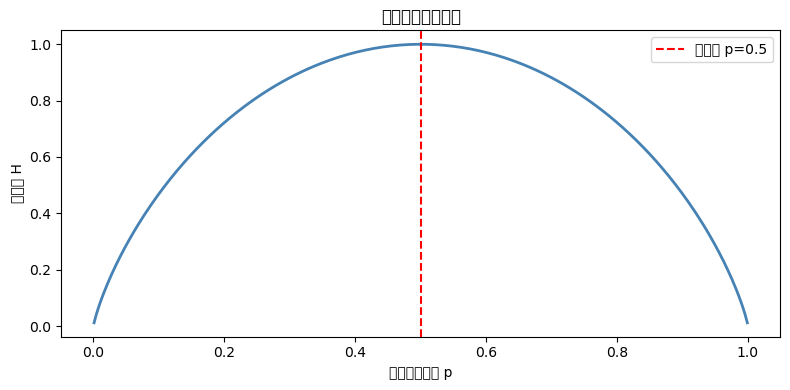

全为正类 [1,0]      → 熵 = -0.0000  （最纯净）
五五开  [0.5, 0.5]  → 熵 = 1.0000  （最混乱）
七三开  [0.7, 0.3]  → 熵 = 0.8813
三分类均等[1/3,1/3,1/3] → 熵 = 1.5850


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(probs):
    probs = np.array(probs)
    probs = probs[probs > 0]  # 排除 p=0 避免 log(0)
    return -np.sum(probs * np.log2(probs))

# 二分类场景：p 为正类比例，1-p 为负类比例
p_values = np.linspace(0.001, 0.999, 300)
entropies = [entropy([p, 1 - p]) for p in p_values]

plt.figure(figsize=(8, 4))
plt.plot(p_values, entropies, color='steelblue', linewidth=2)
plt.axvline(0.5, color='red', linestyle='--', label='最大熵 p=0.5')
plt.xlabel('正类样本比例 p')
plt.ylabel('信息熵 H')
plt.title('二分类信息熵曲线')
plt.legend()
plt.tight_layout()
plt.show()

# 具体案例对比
print(f"全为正类 [1,0]      → 熵 = {entropy([1, 0]):.4f}  （最纯净）")
print(f"五五开  [0.5, 0.5]  → 熵 = {entropy([0.5, 0.5]):.4f}  （最混乱）")
print(f"七三开  [0.7, 0.3]  → 熵 = {entropy([0.7, 0.3]):.4f}")
print(f"三分类均等[1/3,1/3,1/3] → 熵 = {entropy([1/3,1/3,1/3]):.4f}")

## 2. 条件熵（Conditional Entropy）

在**已知特征 $A$** 的条件下，数据集 $D$ 的条件熵：

$$H(D|A) = \sum_{v=1}^{V} \frac{|D_v|}{|D|} H(D_v)$$

- 特征 $A$ 有 $V$ 个取值，$D_v$ 是 $A$ 取第 $v$ 个值时的子集
- 条件熵 = 按各子集大小**加权**后的平均熵
- 条件熵越小，说明用特征 $A$ 分裂后数据越纯净，特征越有价值

## 3. 信息增益（Information Gain）—— ID3 算法核心

$$\text{Gain}(D, A) = H(D) - H(D|A)$$

**信息增益 = 分裂前熵 − 分裂后条件熵**

表示使用特征 $A$ 分裂后，数据不确定性减少了多少。**选信息增益最大的特征**作为当前节点的分裂依据。

> ID3 的缺陷：偏向选取**取值数量多**的特征（如 ID 列），因为分得越细，每个子集就越纯，但泛化能力差。

In [2]:
import pandas as pd
from collections import Counter

# 天气-打球数据集（经典示例）
data = pd.DataFrame({
    '天气':   ['晴','晴','阴','雨','雨','雨','阴','晴','晴','雨','晴','阴','阴','雨'],
    '温度':   ['热','热','热','适中','冷','冷','冷','适中','冷','适中','适中','适中','热','适中'],
    '湿度':   ['高','高','高','高','正常','正常','正常','高','正常','正常','正常','高','正常','高'],
    '风力':   ['弱','强','弱','弱','弱','强','强','弱','弱','弱','强','强','弱','强'],
    '打球':   ['否','否','是','是','是','否','是','否','是','是','是','是','是','否']
})

def calc_entropy(labels):
    total = len(labels)
    counts = Counter(labels)
    return -sum((c / total) * np.log2(c / total) for c in counts.values())

def calc_info_gain(df, feature, target):
    H_D = calc_entropy(df[target])          # 分裂前熵
    total = len(df)
    H_DA = 0
    for val, subset in df.groupby(feature):
        H_DA += (len(subset) / total) * calc_entropy(subset[target])
    return H_D - H_DA

features = ['天气', '温度', '湿度', '风力']
H_root = calc_entropy(data['打球'])
print(f"根节点信息熵 H(D) = {H_root:.4f}\n")
print("各特征信息增益：")
for f in features:
    gain = calc_info_gain(data, f, '打球')
    print(f"  Gain(D, {f}) = {gain:.4f}")
print("\n→ 信息增益最大的特征将被选为根节点分裂特征")

根节点信息熵 H(D) = 0.9403

各特征信息增益：
  Gain(D, 天气) = 0.2467
  Gain(D, 温度) = 0.0292
  Gain(D, 湿度) = 0.1518
  Gain(D, 风力) = 0.0481

→ 信息增益最大的特征将被选为根节点分裂特征


## 4. 信息增益率（Gain Ratio）—— C4.5 算法核心

为了修正 ID3 偏向多取值特征的缺陷，C4.5 引入**分裂信息（Split Information）**作为惩罚项：

$$\text{SplitInfo}(D, A) = -\sum_{v=1}^{V} \frac{|D_v|}{|D|} \log_2 \frac{|D_v|}{|D|}$$

$$\text{GainRatio}(D, A) = \frac{\text{Gain}(D, A)}{\text{SplitInfo}(D, A)}$$

分裂越细（取值越多），SplitInfo 越大，GainRatio 自然被压低，从而惩罚过细的分裂。

In [3]:
def calc_split_info(df, feature):
    total = len(df)
    return -sum(
        (len(subset) / total) * np.log2(len(subset) / total)
        for _, subset in df.groupby(feature)
    )

print("各特征 信息增益 vs 信息增益率：")
print(f"{'特征':<6} {'Gain':>8} {'SplitInfo':>12} {'GainRatio':>12}")
print("-" * 42)
for f in features:
    gain = calc_info_gain(data, f, '打球')
    si   = calc_split_info(data, f)
    gr   = gain / si if si > 0 else 0
    print(f"{f:<6} {gain:>8.4f} {si:>12.4f} {gr:>12.4f}")

各特征 信息增益 vs 信息增益率：
特征         Gain    SplitInfo    GainRatio
------------------------------------------
天气       0.2467       1.5774       0.1564
温度       0.0292       1.5567       0.0188
湿度       0.1518       1.0000       0.1518
风力       0.0481       0.9852       0.0488


## 5. 基尼系数（Gini Index）—— CART 算法核心

CART（Classification and Regression Trees）使用**基尼系数**而非熵来衡量不纯度，计算更快：

$$\text{Gini}(D) = 1 - \sum_{k=1}^{K} p_k^2$$

使用特征 $A$ 的某个切分点将 $D$ 分为 $D_1, D_2$：

$$\text{Gini}(D, A) = \frac{|D_1|}{|D|}\text{Gini}(D_1) + \frac{|D_2|}{|D|}\text{Gini}(D_2)$$

**选择 Gini 最小的切分**。

| 指标 | 值域 | 纯净时 | 最混乱时（二分类） |
|------|------|--------|--------------------|
| 信息熵 | $[0, \log_2 K]$ | 0 | 1.0 |
| 基尼系数 | $[0, 1-1/K]$ | 0 | 0.5 |

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2560131750.py:13: UserWarning: Glyph 32431 (\

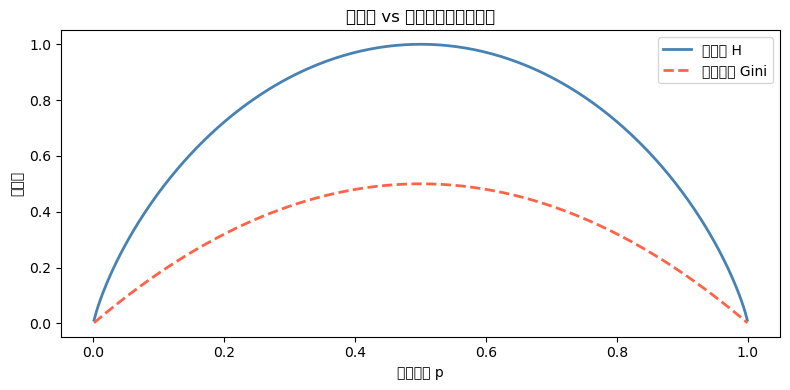

两者形状相近，基尼系数计算量更小，sklearn 的 DecisionTreeClassifier 默认使用基尼系数


In [4]:
# 对比熵与基尼系数的曲线形状
p = np.linspace(0.001, 0.999, 300)
gini   = 1 - p**2 - (1-p)**2
ent    = -p * np.log2(p) - (1-p) * np.log2(1-p)

plt.figure(figsize=(8, 4))
plt.plot(p, ent,  label='信息熵 H', color='steelblue', linewidth=2)
plt.plot(p, gini, label='基尼系数 Gini', color='tomato', linewidth=2, linestyle='--')
plt.xlabel('正类比例 p')
plt.ylabel('不纯度')
plt.title('信息熵 vs 基尼系数（二分类）')
plt.legend()
plt.tight_layout()
plt.show()

print("两者形状相近，基尼系数计算量更小，sklearn 的 DecisionTreeClassifier 默认使用基尼系数")

## 6. 三种算法对比

| 算法 | 分裂标准 | 树结构 | 特点 |
|------|----------|--------|------|
| **ID3** | 信息增益 | 多叉树 | 偏向多取值特征，不支持连续特征，不剪枝 |
| **C4.5** | 信息增益率 | 多叉树 | 修正 ID3 偏差，支持连续特征，后剪枝 |
| **CART** | 基尼系数（分类） / MSE（回归） | 二叉树 | 速度快，既做分类也做回归，支持剪枝，sklearn 默认实现 |

## 7. 决策树的构建过程（递归）

```
BuildTree(D, Features):
  1. 若 D 中所有样本同属一类 → 返回叶节点（该类别）
  2. 若 Features 为空          → 返回叶节点（多数类别）
  3. 选择最优特征 A* = argmax Gain(D, A)
  4. 以 A* 创建分支节点
  5. 对 A* 的每个取值 v：
       D_v = D 中 A*=v 的子集
       子节点 = BuildTree(D_v, Features - {A*})
  6. 返回树
```

**停止条件：**
- 当前节点纯度已足够高（熵/基尼 < 阈值）
- 样本数量小于最小分裂阈值
- 树深度达到上限

## 8. 过拟合与剪枝（Pruning）

决策树容易过拟合（训练集完美拟合，测试集效果差）。

**预剪枝（Pre-pruning）**：在构建过程中提前停止
- 限制最大深度 `max_depth`
- 限制叶节点最少样本数 `min_samples_leaf`
- 限制内部节点分裂所需最少样本数 `min_samples_split`

**后剪枝（Post-pruning）**：先长满再裁减
- CART 使用**代价复杂度剪枝**（`ccp_alpha` 参数），惩罚叶节点数量
- $\alpha$ 越大，剪枝越激进，树越简单

## 9. sklearn 实现决策树分类

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# criterion='entropy' 使用信息增益；'gini' 使用基尼系数
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_gini    = DecisionTreeClassifier(criterion='gini',    max_depth=4, random_state=42)

clf_entropy.fit(X_train, y_train)
clf_gini.fit(X_train, y_train)

acc_e = accuracy_score(y_test, clf_entropy.predict(X_test))
acc_g = accuracy_score(y_test, clf_gini.predict(X_test))

print(f"信息熵 (entropy) 准确率: {acc_e:.4f}")
print(f"基尼系数 (gini)  准确率: {acc_g:.4f}")
print()
print("分类报告（基尼系数模型）:")
print(classification_report(y_test, clf_gini.predict(X_test), target_names=iris.target_names))

信息熵 (entropy) 准确率: 1.0000
基尼系数 (gini)  准确率: 1.0000

分类报告（基尼系数模型）:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 10. 决策树可视化

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 40482 (\N{CJK UNIFIED IDEOGRAPH-9E22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 23614 (\N{CJK UNIFIED IDEOGRAPH-5C3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 33457 (\N{CJK UNIFIED IDEOGRAPH-82B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2584101747.py:13: UserWarning: Glyph 26641 (\

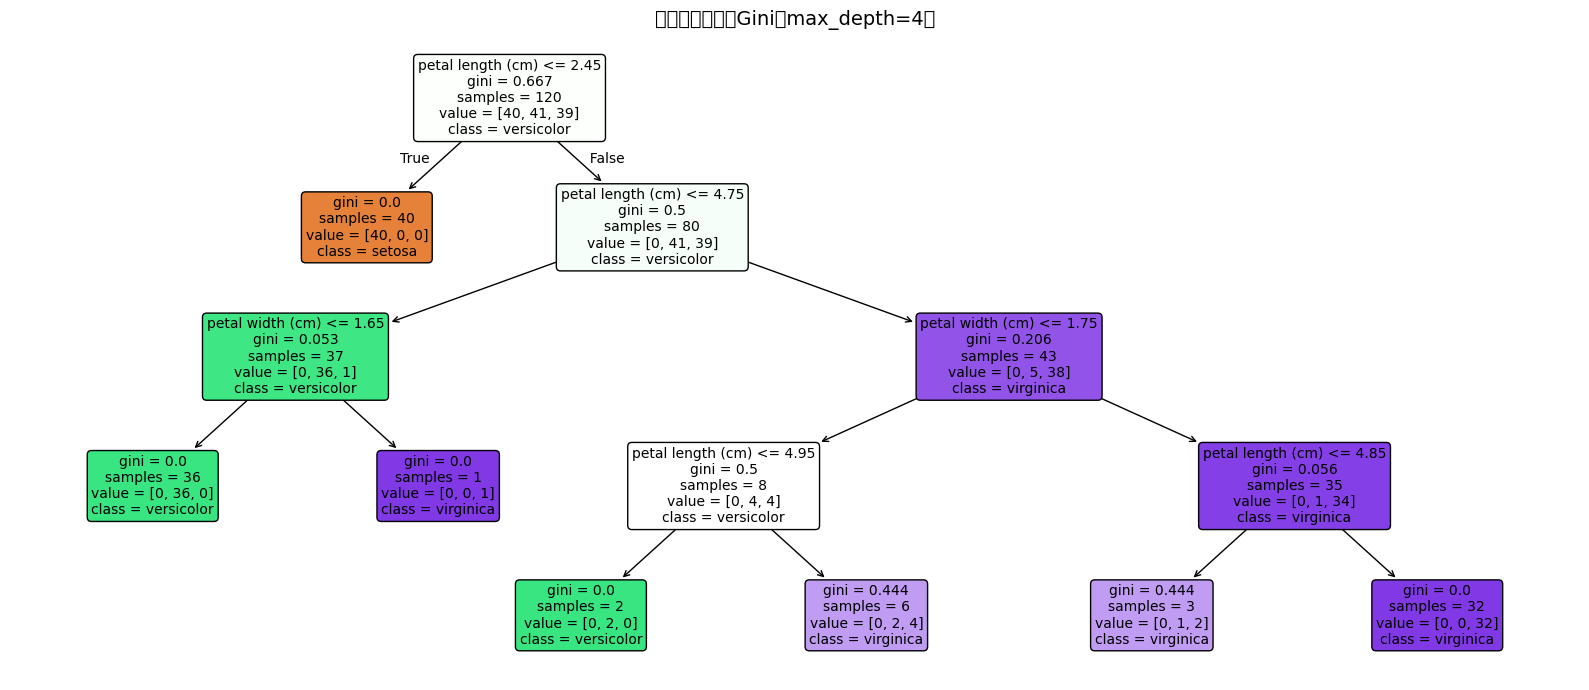

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    clf_gini,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,          # 颜色深浅反映纯度
    rounded=True,
    fontsize=10
)
plt.title('鸢尾花决策树（Gini，max_depth=4）', fontsize=14)
plt.tight_layout()
plt.show()

## 11. 特征重要性

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\4242747424.py:11: UserWarning: Glyph 37325 (\

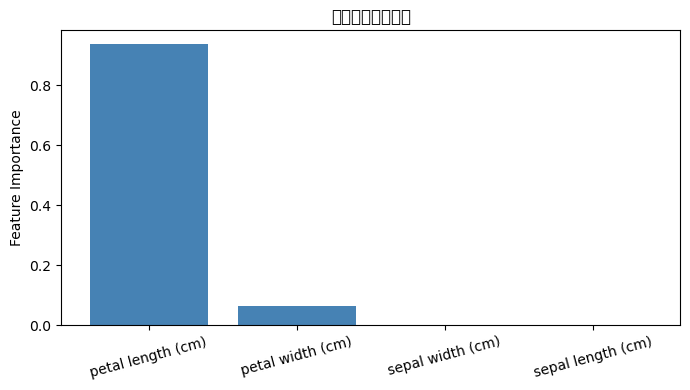

  petal length (cm)         0.9363
  petal width (cm)          0.0637
  sepal width (cm)          0.0000
  sepal length (cm)         0.0000


In [7]:
importances = clf_gini.feature_importances_
feat_names  = iris.feature_names

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(range(len(importances)), importances[sorted_idx], color='steelblue')
plt.xticks(range(len(importances)), [feat_names[i] for i in sorted_idx], rotation=15)
plt.ylabel('Feature Importance')
plt.title('决策树特征重要性')
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"  {feat_names[i]:<25} {importances[i]:.4f}")

## 12. 用 ccp_alpha 控制后剪枝

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 26525 (\N{CJK UNIFIED IDEOGRAPH-679D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\1756816410.py:27: UserWarning: Glyph 24378 (\

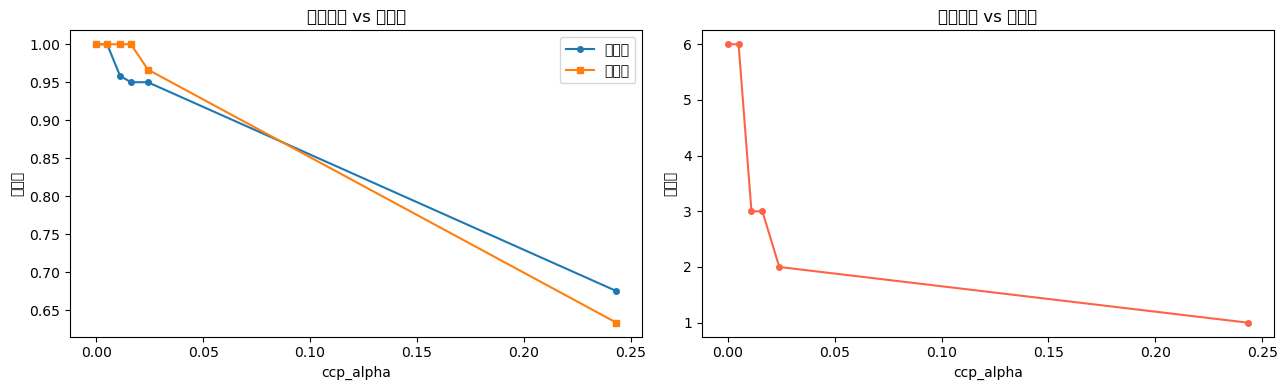

alpha 越大 → 树越矮 → 越简单，但过大会欠拟合


In [8]:
# 获取剪枝路径上所有 alpha 值
path = clf_gini.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # 去掉最后一个（空树）

train_scores, test_scores, depths = [], [], []
for alpha in alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf.predict(X_test)))
    depths.append(clf.get_depth())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(alphas, train_scores, label='训练集', marker='o', markersize=4)
ax1.plot(alphas, test_scores,  label='测试集', marker='s', markersize=4)
ax1.set_xlabel('ccp_alpha')
ax1.set_ylabel('准确率')
ax1.set_title('剪枝强度 vs 准确率')
ax1.legend()

ax2.plot(alphas, depths, color='tomato', marker='o', markersize=4)
ax2.set_xlabel('ccp_alpha')
ax2.set_ylabel('树深度')
ax2.set_title('剪枝强度 vs 树深度')

plt.tight_layout()
plt.show()
print("alpha 越大 → 树越矮 → 越简单，但过大会欠拟合")

## 13. 决策树回归（CART 回归树）

回归树使用 **MSE（均方误差）** 代替熵/基尼系数作为分裂标准：

$$\text{MSE}(D) = \frac{1}{|D|}\sum_{i \in D}(y_i - \bar{y}_D)^2$$

叶节点的预测值 = 该节点所有样本的**均值**。

C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_65920\2669444011.py:20: UserWarning: Glyph 21516 (\N{CJK UNIFI

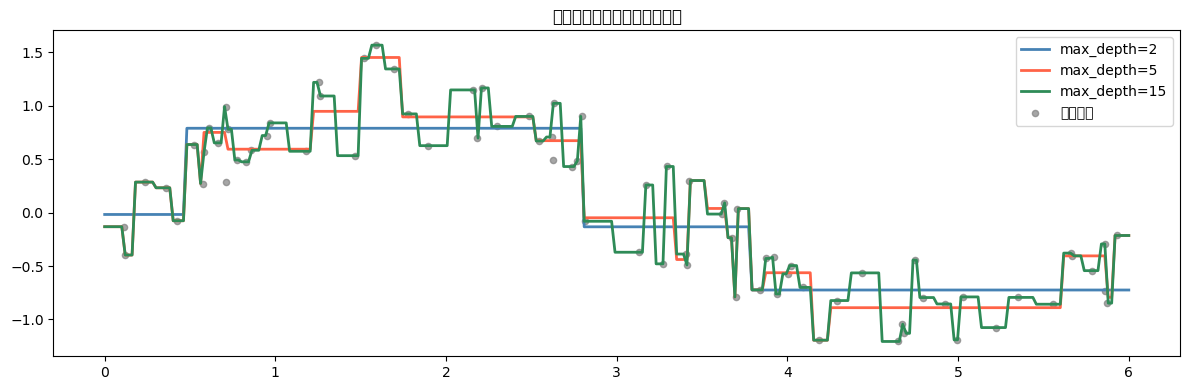

深度太小 → 欠拟合（台阶太少）；深度太大 → 过拟合（锯齿状）


In [9]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(0)
X_reg = np.sort(np.random.rand(80, 1) * 6, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(80) * 0.3

X_plot = np.linspace(0, 6, 300).reshape(-1, 1)

plt.figure(figsize=(12, 4))
colors = ['steelblue', 'tomato', 'seagreen']
for i, depth in enumerate([2, 5, 15]):
    reg = DecisionTreeRegressor(max_depth=depth)
    reg.fit(X_reg, y_reg)
    plt.plot(X_plot, reg.predict(X_plot), label=f'max_depth={depth}',
             color=colors[i], linewidth=2)

plt.scatter(X_reg, y_reg, color='gray', s=20, alpha=0.7, label='训练数据')
plt.title('回归树：不同深度的拟合效果')
plt.legend()
plt.tight_layout()
plt.show()
print("深度太小 → 欠拟合（台阶太少）；深度太大 → 过拟合（锯齿状）")

## 总结

| 知识点 | 核心公式/概念 |
|--------|---------------|
| 信息熵 | $H(D) = -\sum p_k \log_2 p_k$，衡量不纯度 |
| 条件熵 | $H(D|A) = \sum \frac{|D_v|}{|D|} H(D_v)$，用某特征分裂后的加权熵 |
| 信息增益 | $\text{Gain} = H(D) - H(D|A)$，ID3 的分裂标准 |
| 信息增益率 | $\text{GainRatio} = \text{Gain} / \text{SplitInfo}$，C4.5 修正偏差 |
| 基尼系数 | $\text{Gini} = 1 - \sum p_k^2$，CART 分类标准（sklearn 默认） |
| 回归树 | 用 MSE 分裂，叶节点取均值 |
| 剪枝 | 预剪枝（限制深度/样本数）；后剪枝（ccp_alpha）|

**使用建议：**
- 单棵决策树容易过拟合，生产环境更常用集成方法（随机森林、GBDT、XGBoost）
- 决策树优点：可解释性强，无需特征缩放，能处理混合类型特征